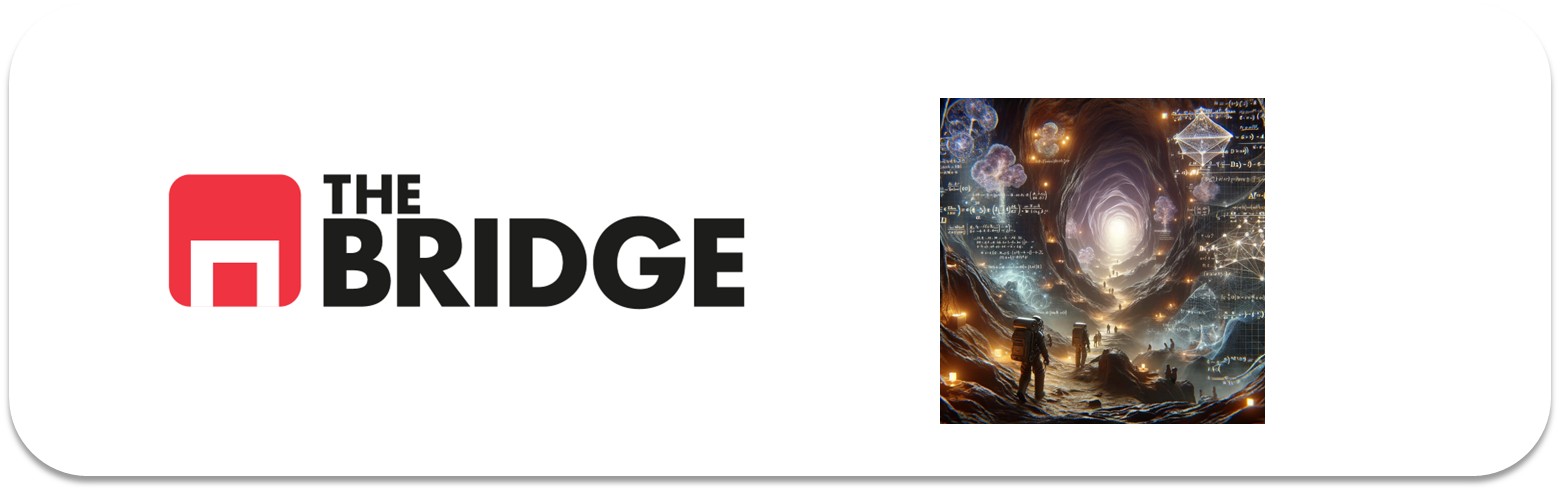

## PRACTICA OBLIGATORIA: **Introducción Keras**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Descripción de la práctica

En esta práctica el objetivo es jugar con el framework de [Keras](https://www.tensorflow.org/guide/keras) a partir de la construcción de un modelo DL sobre MLP para clasificar imagenes de ropa como camisetas, zapatos y zapatillas deportivas.

Vamos a utilizar el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles)

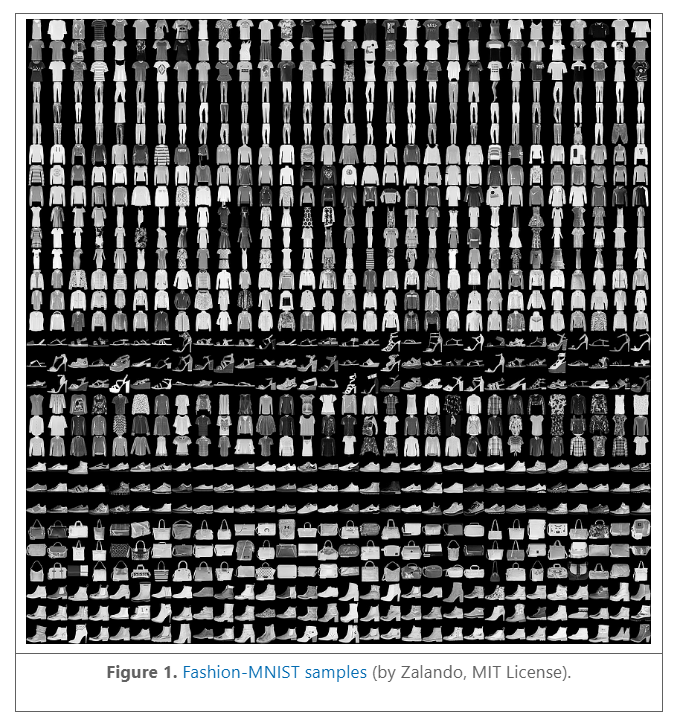

La *class* de ropa que la imagen representa:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset, es recomendable construirse una lista o un diccionario que permita mapear la clase a el tipo literal.

Se pide:

0. Cargar el dataset desde TensorFlow (tienes una celda ya proporcionada para hacerlo) y visualiza al menos 5 instancias, se recomienda crear una función que permita visualizar subsets de instancias con su etiqueta adecuada. 

1. Construir un modelo DL basado en MLP, es decir una red densa que clasifique las imágenes de ropa. No vas a necesitar más de 1 o 2 capas ocultas. Recuerda que es un problema de clasificación multiclase para configurar correctamente la capa de salida en número de neuronas y función de activiación. Ten en cuenta también que necesitarás utilizar una capa que aplane las imágenes o bien convertir el dataset por tu cuenta.

2. No crees un set de validación, especifica en el entrenamiento que emplee un 20% del dataset en validación. Además muestra gráficamente la evolución en el entrenamiento de la pérdida (loss) por un lado (del conjuto de train y del de validación) y la evolución de la métrica escogida (también de train  y de validación). Razona si es conveniente tener un "callback" de earlystopping, y, en cualquier caso, implementa uno.

3. Finalmente evalua contra test. Muestra el report de clasificación y haz un análisis de los resultados. Para ello, muestra algunas predicciones, el nivel de confianza y si era acertada o no, además muestra la matriz de confusión y analiza en que tipos se confunde más y con que otra clase lo confunde. 

Ejemplo del grafico de predicción más nivel de confianza:

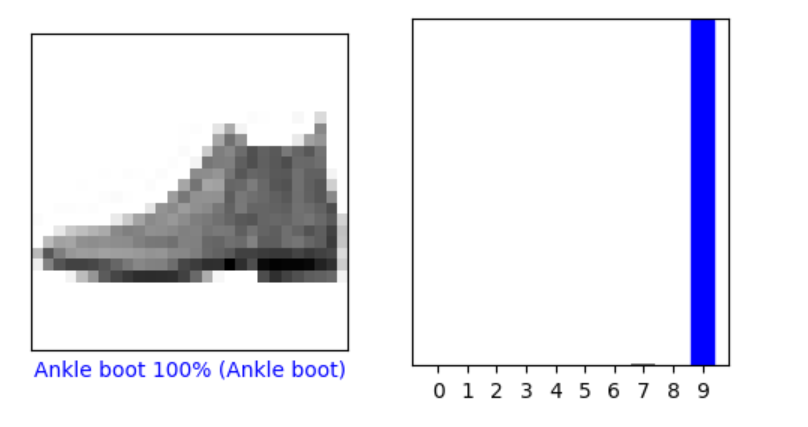

Fíjate que el gráfico de la derecha muestra la probabilidad por clase, de forma que cuanto más alta la probabilidad de la clase elegida más confianza podemos decir que tiene en el resultado. 

**EXTRA**: Como parte extra, obtén los errores de clasificación en los que la confianza del modelo sobre su clasificación errónea supere el 0.7 o 70% (es decir los errores en los que la probabilidad de la clase elegida, equivocadamente, fuera igual o superior a 0.7), de existir muéstralos y analiza si son de alguna clase específica.

```python

# Cargar FASHION_MNIST

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

```

0. Carga de datos

In [ ]:
# Construcción del diccionario de clases
CLASS_NAMES = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}
print('Clases:', CLASS_NAMES)

Clases: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


In [ ]:
# Celda de carga proporcionada. Keras incluye Fashion MNIST directamente, devuelve splits y train ya hechos
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f'X_train shape: {X_train.shape}  — {X_train.shape[0]} imágenes de {X_train.shape[1]}×{X_train.shape[2]} píxeles')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (60000, 28, 28)  — 60000 imágenes de 28×28 píxeles
X_test shape:  (10000, 28, 28)
y_train shape: (60000,)
y_test shape:  (10000,)


In [4]:
# MiniEDA - distribución del target

target_series = pd.Series(y_train).map(CLASS_NAMES)
print('Distribución del target en train:')
print(target_series.value_counts(normalize=True).round(3))

Distribución del target en train:
Ankle boot     0.1
T-shirt/top    0.1
Dress          0.1
Pullover       0.1
Sneaker        0.1
Sandal         0.1
Trouser        0.1
Shirt          0.1
Coat           0.1
Bag            0.1
Name: proportion, dtype: float64


In [ ]:
# dataset balanceado perfectamente

In [ ]:
# Visualización de instancias

def plot_instances(X, y, indices, cols=5, cmap='Greys'):
    """Visualiza las imágenes indicadas por 'indices' con su etiqueta."""
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.5))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()
    for ax, idx in zip(axes, indices):
        ax.imshow(X[idx], cmap=cmap)
        ax.set_title(CLASS_NAMES[y[idx]], fontsize=9)
        ax.axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Mostramos las primeras 10 instancias del train
plot_instances(X_train, y_train, indices=range(10))

In [ ]:
# Mostramos 10 instancias aleatorias
rng = np.random.default_rng(seed=42)
random_idx = rng.integers(0, len(X_train), size=10)
plot_instances(X_train, y_train, indices=random_idx)

In [ ]:
# Escalado

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print(f'Rango tras escalado — min: {X_train.min():.1f}  max: {X_train.max():.1f}')

Rango tras escalado — min: 0.0  max: 1.0


1. Construcción del modelo MLP

In [6]:
capas = [
    # Flatten aplana la imagen 28x28 en un vector de 784 valores
    # Es equivalente a hacer un reshape(-1, 28*28)
    keras.layers.Flatten(input_shape=(28, 28)),

    # Capa oculta 1
    keras.layers.Dense(256, activation='relu'),

    # Capa oculta 2
    keras.layers.Dense(128, activation='relu'),

    # Capa de salida: 10 neuronas (una por clase) + softmax
    # softmax convierte las salidas en probabilidades que suman 1
    keras.layers.Dense(10, activation='softmax')
]

model = keras.models.Sequential(capas)

c:\Users\PC\Desktop\ds_bootcamp\DS-Online-Elena-Acosta\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.summary()
# La primera Dense tiene 784 entradas × 256 neuronas + 256 bias = 200.960 params
# La segunda Dense: 256 × 128 + 128 = 32.896 params
# La salida: 128 × 10 + 10 = 1.290 params

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compilación

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

2. Entrenamiento

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',   # monitorizamos la pérdida en validación
    patience=5, # esperamos 5 épocas sin mejora antes de parar
    restore_best_weights=True  # restauramos los pesos de la mejor época
)

print('Callback de EarlyStopping configurado.')

Callback de EarlyStopping configurado.


In [11]:
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,  # máximo de épocas; EarlyStopping parará antes si procede
    validation_split=0.2, # 20% del train se reserva para validación
    callbacks=[early_stopping],
    verbose=1
)

print(f'\nEntrenamiento parado en la época: {len(history.epoch)}')

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9114 - loss: 0.2320 - val_accuracy: 0.8842 - val_loss: 0.3292
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9165 - loss: 0.2213 - val_accuracy: 0.8868 - val_loss: 0.3177
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9191 - loss: 0.2142 - val_accuracy: 0.8891 - val_loss: 0.3206
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9221 - loss: 0.2044 - val_accuracy: 0.8877 - val_loss: 0.3294
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9237 - loss: 0.2021 - val_accuracy: 0.8959 - val_loss: 0.3171

Entrenamiento parado en la época: 5


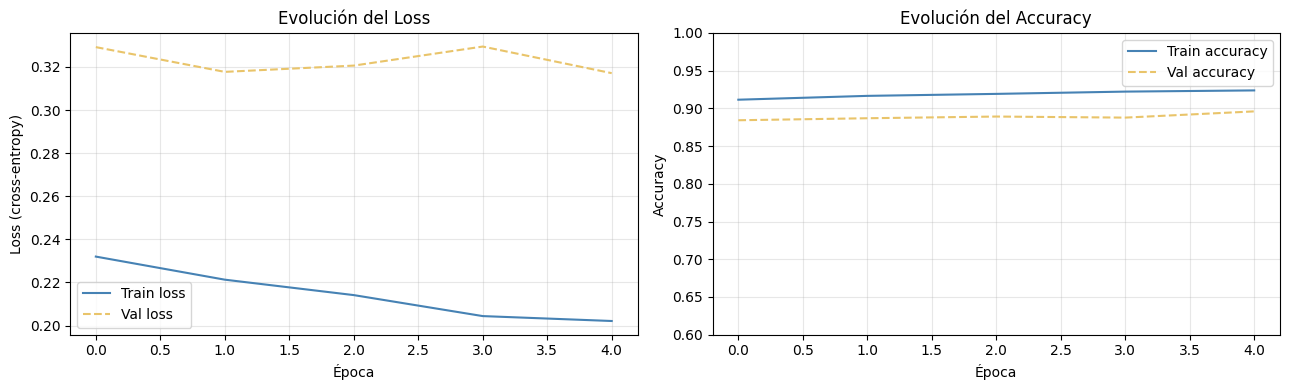

In [13]:
# Curvas de entrenamiento

hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(hist['epoch'], hist['loss'],label='Train loss', color='steelblue')
axes[0].plot(hist['epoch'], hist['val_loss'], label='Val loss', color='#E9C46A', linestyle='--')
axes[0].set_title('Evolución del Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(hist['epoch'], hist['accuracy'], label='Train accuracy', color='steelblue')
axes[1].plot(hist['epoch'], hist['val_accuracy'], label='Val accuracy', color='#E9C46A', linestyle='--')
axes[1].set_title('Evolución del Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.6, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3. Evaluación sobre test

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}({test_acc*100:.2f}%)')

Test loss: 0.3573
Test accuracy: 0.8751(87.51%)


In [16]:
# Predicciones

# model.predict devuelve la probabilidad de cada una de las 10 clases
probs = model.predict(X_test, verbose=0)

# La clase predicha es la de mayor probabilidad
y_pred = np.argmax(probs, axis=1)

print(f'Forma de probs: {probs.shape} — una fila por imagen, una columna por clase')
print(f'Primeras 5 predicciones: {y_pred[:5]}')
print(f'Primeras 5 etiquetas reales: {y_test[:5]}')


Forma de probs: (10000, 10) — una fila por imagen, una columna por clase
Primeras 5 predicciones: [9 2 1 1 6]
Primeras 5 etiquetas reales: [9 2 1 1 6]


In [17]:
# Classification Report

print('Classification Report — conjunto de test')
print('=' * 60)
print(classification_report(
    y_test, y_pred,
    target_names=list(CLASS_NAMES.values())
))

Classification Report — conjunto de test
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.88      0.66      0.75      1000
       Dress       0.93      0.84      0.89      1000
        Coat       0.69      0.91      0.79      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.68      0.70      0.69      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.97      0.92      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [18]:
# Visualización de predicciones con nivel de confianza

def plot_prediction(idx, X, y_true, y_pred, probs):
    """Muestra la imagen con predicción + nivel de confianza por clase."""
    pred_class  = y_pred[idx]
    true_class  = y_true[idx]
    confidence  = probs[idx][pred_class] * 100
    is_correct  = pred_class == true_class

    color = 'blue' if is_correct else 'red'

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(8, 3),
                                          gridspec_kw={'width_ratios': [1, 1.5]})

    # Imagen
    ax_img.imshow(X[idx], cmap='Greys')
    ax_img.axis('off')
    label_text = (f"{CLASS_NAMES[pred_class]} {confidence:.0f}%\n"
                  f"({CLASS_NAMES[true_class]})")
    ax_img.set_xlabel(label_text, color=color, fontsize=10)

    # Barras de probabilidad
    bar_colors = ['blue' if i == pred_class else 'lightgray' for i in range(10)]
    ax_bar.barh(range(10), probs[idx] * 100, color=bar_colors)
    ax_bar.set_yticks(range(10))
    ax_bar.set_yticklabels(list(CLASS_NAMES.values()), fontsize=8)
    ax_bar.set_xlim(0, 105)
    ax_bar.set_xlabel('Probabilidad (%)')
    ax_bar.invert_yaxis()  # clase 0 arriba

    plt.tight_layout()
    plt.show()

--- Predicciones CORRECTAS ---


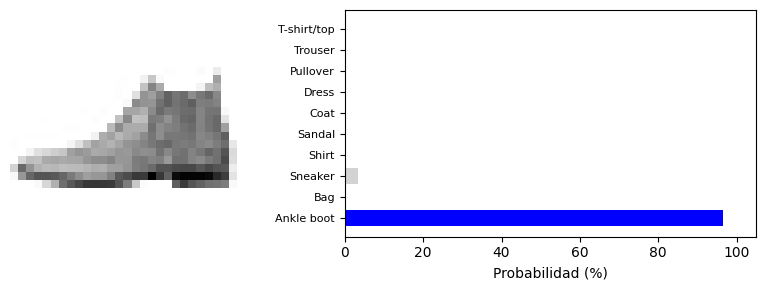

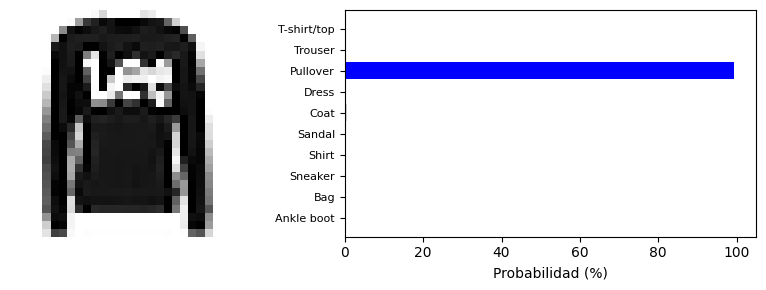

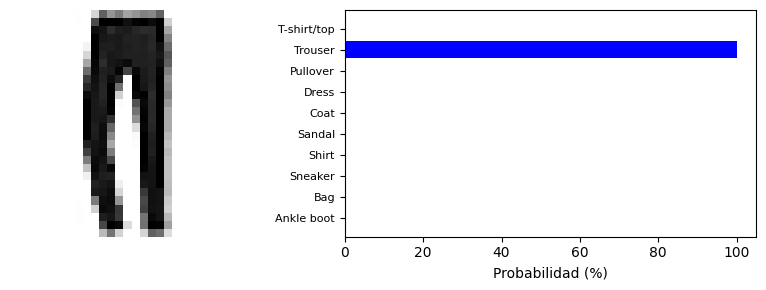

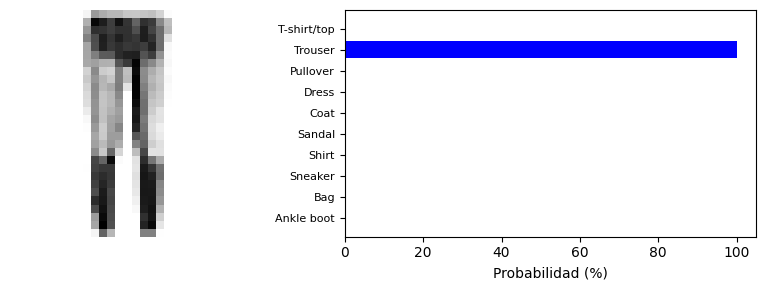

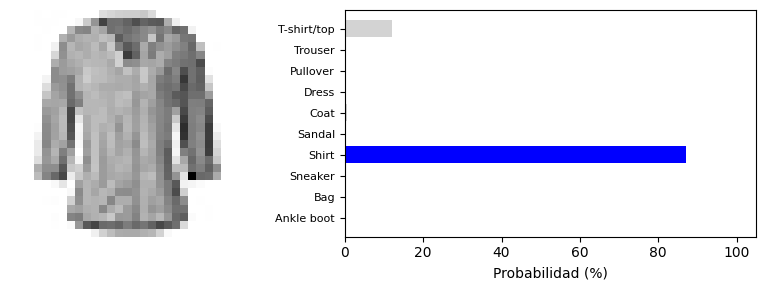

In [19]:
# Mostramos 5 predicciones correctas
correct_idx = np.where(y_pred == y_test)[0][:5]
print('--- Predicciones CORRECTAS ---')
for i in correct_idx:
    plot_prediction(i, X_test, y_test, y_pred, probs)

--- Predicciones INCORRECTAS ---


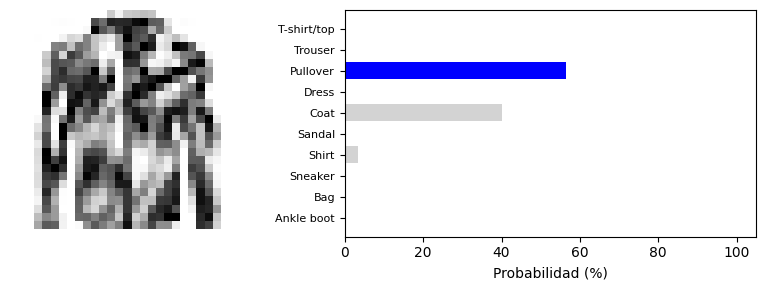

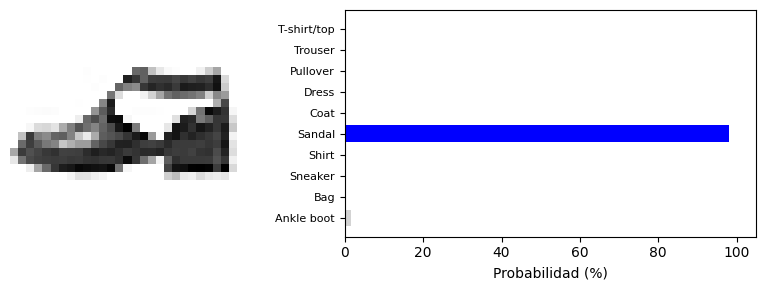

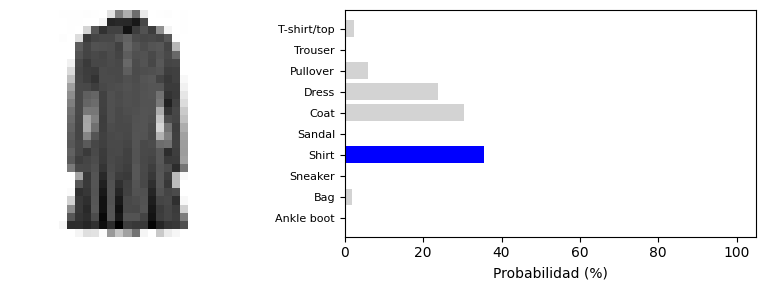

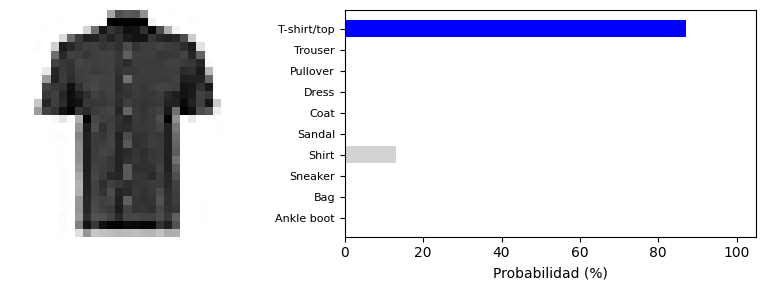

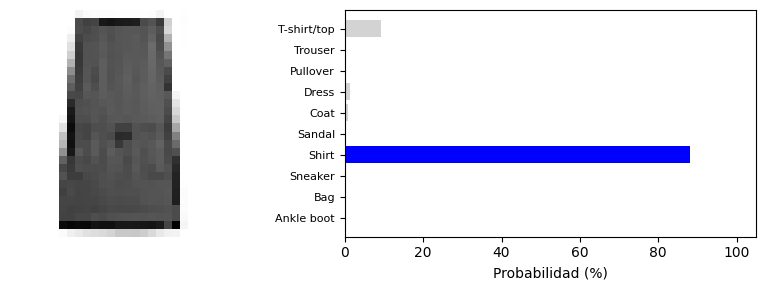

In [20]:
# Mostramos 5 predicciones incorrectas
wrong_idx = np.where(y_pred != y_test)[0][:5]
print('--- Predicciones INCORRECTAS ---')
for i in wrong_idx:
    plot_prediction(i, X_test, y_test, y_pred, probs)

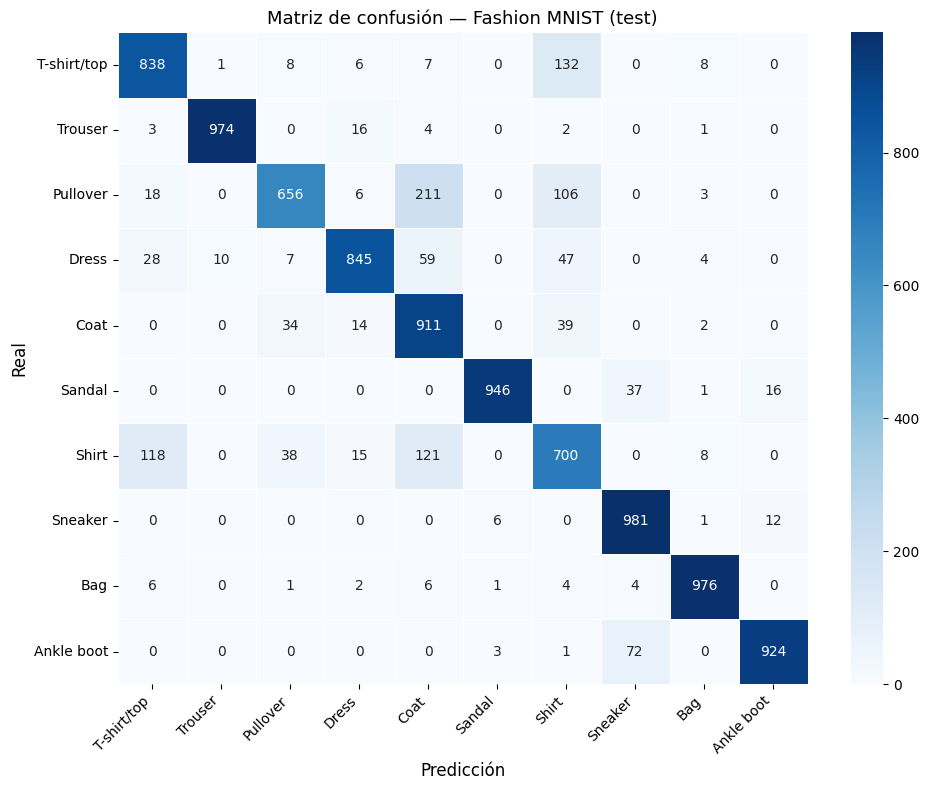

In [21]:
# Matriz de confusión


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=list(CLASS_NAMES.values()),
    yticklabels=list(CLASS_NAMES.values()),
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de confusión — Fashion MNIST (test)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

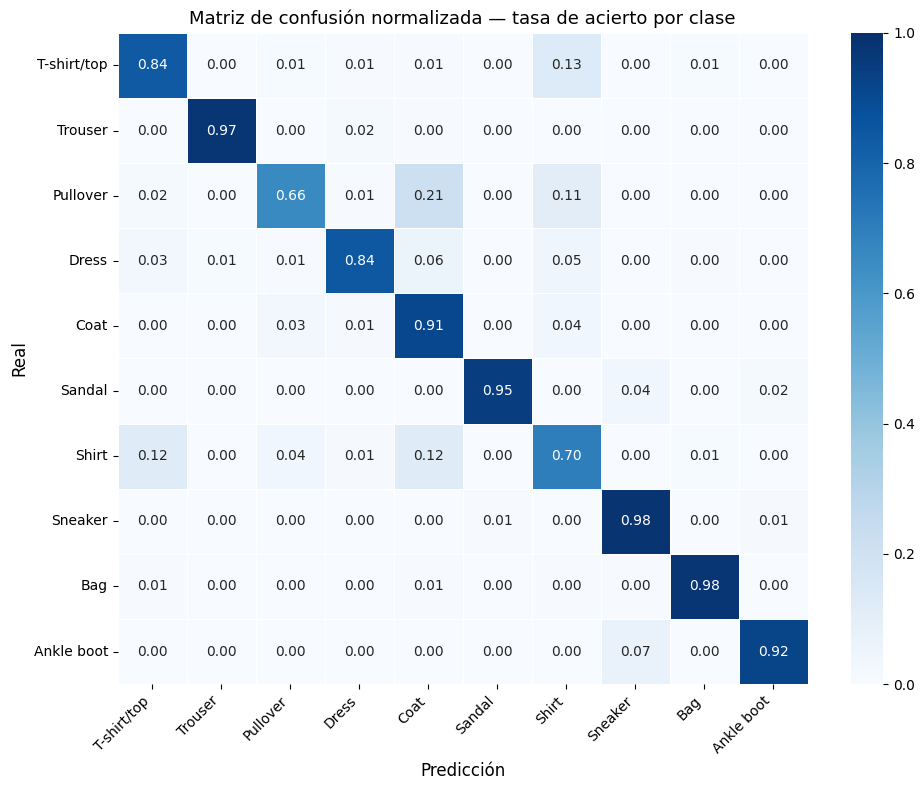

In [22]:
# Versión normalizada (porcentaje por fila = tasa de acierto por clase real)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    vmin=0, vmax=1,
    xticklabels=list(CLASS_NAMES.values()),
    yticklabels=list(CLASS_NAMES.values()),
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de confusión normalizada — tasa de acierto por clase', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Conclusión del modelo:
Funcina bien (> 88% accuracy) 